# El Niño and the waves at *your* station

Sea level is half of the coastal water-level story; waves are the other half. This
notebook asks the same two questions of the wave field that notebook 11 asked of
sea level — what is the seasonal cycle, and what do El Niño winters add? — using
CDIP's MOP model, which predicts hourly waves on ~100-m-spaced transects along the
whole California coast. Two things are different from sea level:

- **The record starts in 2000** (MOP needs the modern buoy network), so 1982–83
  and 1997–98 do not exist for waves. Events here are 2015–16, 2023–24, 2026–27.
- **Your gauge hides from waves.** Tide gauges live in harbors precisely because
  waves are small there, so each station has been assigned a *wave transect* on
  the nearest natural beach — away from jetties, breakwaters, and dredged
  channels, whose bathymetry is not a normal beach. The map below shows yours.

Each site's transect was chosen for you (the vetting is in
`reference/12_el_nino_waves_complete.ipynb`); your job is the analysis.

In [1]:
import re
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LightSource
from PIL import Image

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "README.md").exists(), "Open the course project folder first."

MOP_RAW = PROJECT_ROOT / "data" / "raw" / "mop"           # raw wave downloads
CODE_DL = PROJECT_ROOT / "data" / "code-downloaded"        # lookup tables, basemaps
MOP_RAW.mkdir(parents=True, exist_ok=True)
(CODE_DL / "basemaps").mkdir(parents=True, exist_ok=True)

In [2]:
# gauge -> (gauge lat, gauge lon, wave transect, transect window for the map)
SITES = {
    "San Diego":     (32.7133, -117.1733, "D0179", ("D", 149, 209)),
    "La Jolla":      (32.8667, -117.2567, "D0513", ("D", 470, 560)),
    "Los Angeles":   (33.7200, -118.2717, "L0550", ("L", 480, 620)),
    "Port San Luis": (35.1767, -120.7600, "SL075", ("SL", 40, 195)),
    "Monterey":      (36.6050, -121.8883, "MO832", ("MO", 732, 862)),
    "San Francisco": (37.8067, -122.4650, "SF029", ("SF", 1, 89)),
    "Humboldt Bay":  (40.7667, -124.2167, "HU583", ("HU", 503, 660)),
    "Crescent City": (41.7450, -124.1833, "DN155", ("DN", 130, 226)),
}

MY_SITE = "San Diego"  # TODO: your group's station (Oregon groups: pair up)

GLAT, GLON, MOP_ID, WINDOW = SITES[MY_SITE]
print(MY_SITE, "-> transect", MOP_ID)

San Diego -> transect D0179


## 1. See your site

The map draws your gauge (star), every MOP transect point near it (red dots on
the ~10-m depth contour), and your assigned transect (orange circle) on a NOAA
topobathy elevation model.

**TODO (markdown):** name one geographic feature on this map — a harbor, jetty,
submarine canyon, headland, river mouth — and one sentence on how it should shape
the waves your transect sees.

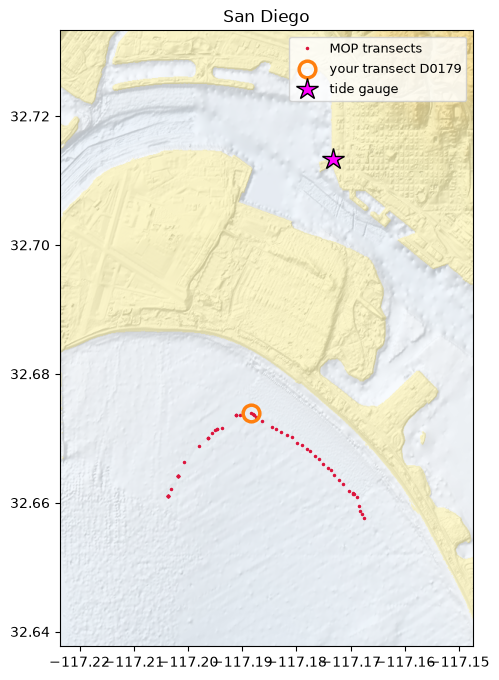

In [3]:
# transect positions come from a lookup table built once for the course
coords = pd.read_csv(CODE_DL / "mop_transect_coords.csv").set_index("mop_id")
county, lo, hi = WINDOW
# MOP IDs are county code + number, zero-padded to five characters total
window_ids = [f"{county}{n:0{5 - len(county)}d}" for n in range(lo, hi + 1)]
sel = coords.loc[coords.index.intersection(window_ids)]

# map frame: everything in the window plus the gauge, with a small margin
pad = 0.02
w, e = min(sel.lon.min(), GLON) - pad, max(sel.lon.max(), GLON) + pad
s, n = min(sel.lat.min(), GLAT) - pad, max(sel.lat.max(), GLAT) + pad

# fetch a topobathy elevation tile for this frame from NOAA (cached on disk)
DEM_URL = ("https://gis.ngdc.noaa.gov/arcgis/rest/services/DEM_mosaics/"
           "DEM_global_mosaic/ImageServer/exportImage")
tag = "_".join(f"{b:.3f}" for b in (w, s, e, n))
dem_file = CODE_DL / "basemaps" / f"student_{MY_SITE.lower().replace(' ', '_')}_{tag}.tif"
if not dem_file.exists():
    size = f"650,{int(650 * (n - s) / (e - w))}"
    urlretrieve(f"{DEM_URL}?bbox={w},{s},{e},{n}&bboxSR=4326&imageSR=4326"
                f"&size={size}&format=tiff&pixelType=F32&f=image", dem_file)
z = np.array(Image.open(dem_file)).astype(float)   # elevation in meters
z[np.abs(z) > 12000] = np.nan                      # mask the server's no-data value
zf = np.where(np.isnan(z), 0.0, z)

fig, ax = plt.subplots(figsize=(8, 8))
extent = (w, e, s, n)
# sea in blues (deeper = darker), land in tans, plus a hillshade for texture
ax.imshow(np.ma.masked_where(zf >= 0, zf), cmap="Blues_r", vmin=-250, vmax=0,
          extent=extent, origin="upper")
ax.imshow(np.ma.masked_where(zf < 0, zf), cmap="YlOrBr", vmin=-60, vmax=500,
          extent=extent, origin="upper")
ax.imshow(LightSource(315, 45).hillshade(zf, vert_exag=3), cmap="gray",
          alpha=0.22, extent=extent, origin="upper")
ax.plot(sel.lon, sel.lat, ".", color="crimson", ms=3, label="MOP transects")
row = coords.loc[MOP_ID]
ax.plot(row.lon, row.lat, "o", mfc="none", mec="tab:orange", ms=12, mew=2.5,
        label=f"your transect {MOP_ID}")
ax.plot(GLON, GLAT, "*", color="magenta", ms=16, mec="k", label="tide gauge")
ax.set_xlim(w, e)
ax.set_ylim(s, n)
# one degree of longitude shrinks with latitude; this keeps the map undistorted
ax.set_aspect(1 / np.cos(np.deg2rad((s + n) / 2)))
ax.set_title(MY_SITE)
ax.legend(loc="best", fontsize=9)
plt.show()

## 2. Load the hourly wave record

Each transect has an hourly `_hindcast` file (2000 through early 2025) and a
rolling `_nowcast` file that reaches the present; together they are a continuous
hourly record of significant wave height Hs. Hours flagged bad become NaN.

In [4]:
MOP_NCSS = "https://thredds.cdip.ucsd.edu/thredds/ncss/point/cdip/model/MOP_alongshore"


def fetch_mop(mop_id, kind):
    """Download one MOP file (kind: 'hindcast' or 'nowcast') if not on disk."""
    target = MOP_RAW / f"{mop_id}_{kind}.nc"
    if target.exists():
        return target
    url = (f"{MOP_NCSS}/{mop_id}_{kind}.nc?var=waveHs&var=waveTp&var=waveDp"
           f"&var=waveFlagPrimary&temporal=all&accept=netcdf")
    urlretrieve(url, target)
    print(f"downloaded {target.name}")
    return target


def load_hourly_hs(mop_id):
    """Hourly significant wave height (m), 2000-present, quality-controlled."""
    parts = []
    for kind in ("hindcast", "nowcast"):
        with xr.open_dataset(fetch_mop(mop_id, kind)) as ds:
            ds = ds.swap_dims({"obs": "time"})        # index by time, not row number
            hs = ds["waveHs"].to_series()
            # QC: keep only hours the model flags as good (flag == 1)
            hs[ds["waveFlagPrimary"].to_series() != 1] = np.nan
            parts.append(hs)
    hs = pd.concat(parts).sort_index()
    return hs[~hs.index.duplicated()]  # hindcast and nowcast overlap by one hour


hourly = load_hourly_hs(MOP_ID)
print(f"{MOP_ID}: {hourly.index[0]:%Y-%m-%d} to {hourly.index[-1]:%Y-%m-%d}, "
      f"{hourly.notna().mean():.1%} good hours")

D0179: 2000-01-01 to 2026-08-13, 99.8% good hours


## 3. Two statistics of the same record

The **monthly mean** answers "what is a typical sea state this month." The
**monthly 98th percentile** — the height the roughest ~15 hours of the month
exceed — answers "how big is a bad week," and damage cares about the second.

**TODO (code):** the second call below still computes the mean, so both panels of
your figure will look identical until you fix it. What `stat` value picks out the
top 2% of hours? (`monthly_stat` accepts `"mean"` or a quantile between 0 and 1.)

Events here: 2015–16 is given. **Add 2023–24 and red 2026–27**, same drill as
notebook 11.

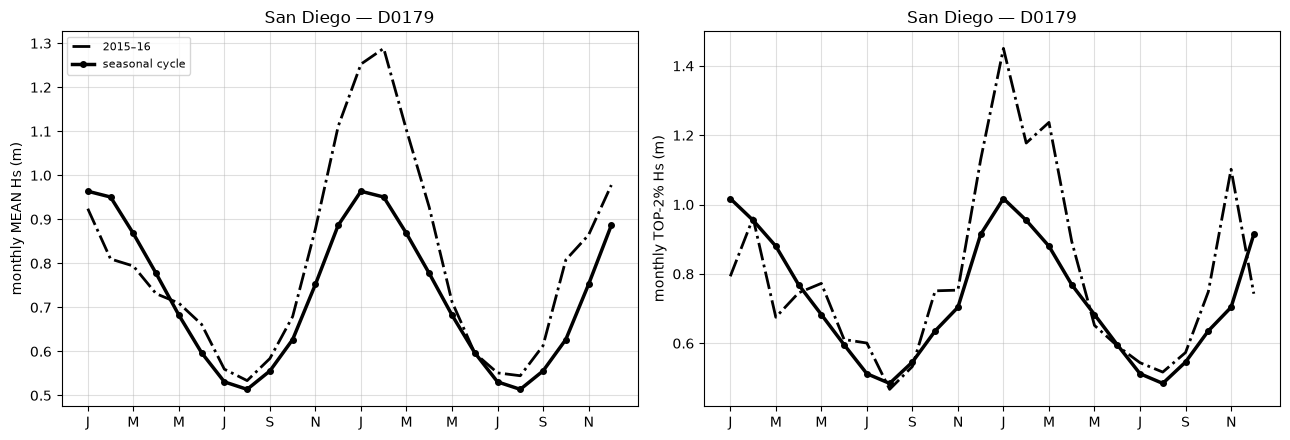

mean-Hs climatology: max month 1, range 0.45 m


In [5]:
WAVE_EVENTS = [
    (2015, "2015–16", dict(color="k", ls="-.", lw=2)),
    # TODO: add (2023, "2023–24", ...) and (2026, "2026–27", ...)
]


def monthly_stat(hourly, stat):
    """Monthly statistic of hourly Hs: "mean" or a quantile like 0.9."""
    grouped = hourly.resample("MS")
    values = grouped.mean() if stat == "mean" else grouped.quantile(stat)
    count = grouped.count()
    # coverage rules: a month needs half its ~720 hours to count, except the
    # current (partial) month, which we keep if it has at least 3 days so far
    keep_last = count.iloc[-1] >= 72
    last_value = values.iloc[-1]
    values[count < 360] = np.nan
    if keep_last:
        values.iloc[-1] = last_value
    return values


# smooth the mean like notebook 11; leave the extreme statistic raw, so every
# point is exactly one month's percentile
mean_hs = monthly_stat(hourly, "mean").rolling(3, center=True, min_periods=2).mean()
p98_hs = monthly_stat(hourly, "mean")  # TODO: this should be the top-2% statistic

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, series, label in [(axes[0], mean_hs, "monthly MEAN Hs (m)"),
                          (axes[1], p98_hs, "monthly TOP-2% Hs (m)")]:
    months = np.arange(1, 25)
    clim = series.groupby(series.index.month).mean()   # 12-month climatology
    for onset, evlabel, style in WAVE_EVENTS:
        # the same two-year window trick as notebook 11
        idx = pd.date_range(f"{onset}-01-01", periods=24, freq="MS")
        ax.plot(months, series.reindex(idx).to_numpy(), label=evlabel, **style)
    ax.plot(months, np.tile(clim.to_numpy(), 2), "k-o", lw=2.5, ms=4,
            markerfacecolor="k", label="seasonal cycle", zorder=2)
    ax.set_xticks(months[::2])
    ax.set_xticklabels(list("JMMJSN") * 2)   # every other month initial
    ax.set_ylabel(label)
    ax.set_title(f"{MY_SITE} — {MOP_ID}")
    ax.grid(alpha=0.4)
axes[0].legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

clim = mean_hs.groupby(mean_hs.index.month).mean()
print(f"mean-Hs climatology: max month {clim.idxmax()}, "
      f"range {clim.max() - clim.min():.2f} m")

## 4. Interpret, then bring numbers to the board

**TODO (markdown):**

1. Which month is your wave maximum? Compare with your *sea level* maximum from
   notebook 11 — in phase, or months apart? (This is the central question for the
   class synthesis.)
2. For each event: how much did it add to the mean, and how much to the top-2%?
   Which statistic carries the El Niño signal?
3. If your wave seasonal cycle surprises you — a La Jolla group might expect
   winter and find April — ask *which statistic* your beach memory is about, and
   whether your transect is sheltered from the winter swell direction. The
   reference notebook works through exactly this case.

**For the board:** transect ID, mean-Hs climatology max month and range, and the
peak departure above climatology (m) of each event, in both statistics.

## Data notes

CDIP MOP v1.1 transect model (O'Reilly et al. 2016); NOAA NCEI topobathy
basemap. Full transect-selection reasoning, all-site maps, and provenance:
`reference/12_el_nino_waves_complete.ipynb`.